In [10]:
import torch
from torchvision import datasets, transforms

In [11]:
data_all = "/kaggle/input/fruit-recognition/train/train"
dataset = datasets.ImageFolder(data_all)

In [12]:
data_train, data_test = torch.utils.data.random_split(dataset, [0.8, 0.2])

In [21]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(10),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ] 
)

In [22]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [31]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [25]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

(224, 224, 3)


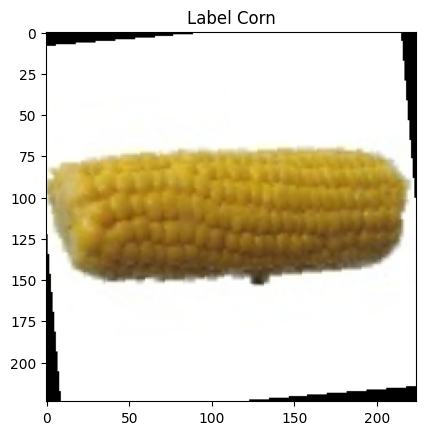

(224, 224, 3)


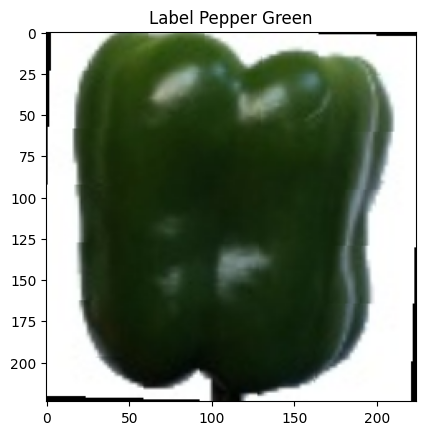

(224, 224, 3)


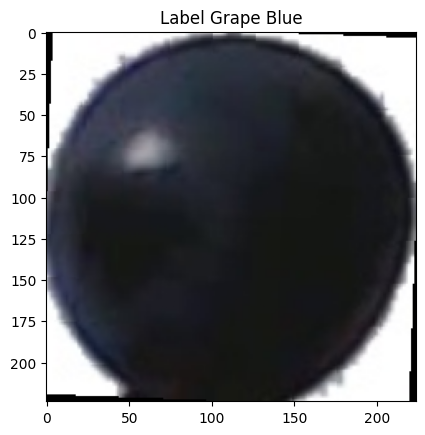

In [17]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

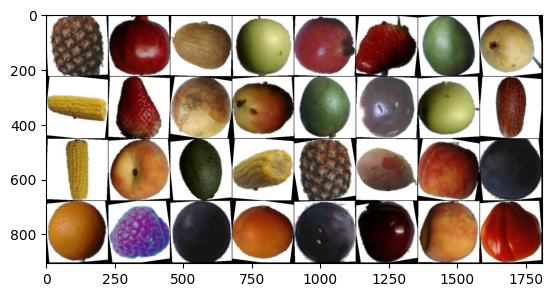

In [18]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [27]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)
)

device = "cuda"
model = model.to(device)

In [28]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.2
)

loss_list = []
loss_test_list = []
for i in range(1):
    
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"test loss: {loss}")

         
        loss_test_list.append(loss.cpu().item())

loss: 3.4968671798706055
loss: 121377.421875
loss: 61830.328125
loss: 77290.046875
loss: 7626.47216796875
loss: 6089.48876953125
loss: 5150.94921875
loss: 1087.677001953125
loss: 416.5016174316406
loss: 45.631595611572266
loss: 5.355105400085449
loss: 4.029237270355225
loss: 4.0205535888671875
loss: 3.917665481567383
loss: 710.3988037109375
loss: 3.7572216987609863
loss: 3.8487823009490967
loss: 3.8255434036254883
loss: 3.7047977447509766
loss: 3.761948823928833
loss: 3.870993137359619
loss: 4.633726596832275
loss: 3.8879852294921875
loss: 3.7397637367248535
loss: 3.7075932025909424
loss: 3.768305778503418
loss: 3.751114845275879
loss: 3.7185864448547363
loss: 3.701894998550415
loss: 3.714301586151123
loss: 3.747980833053589
loss: 3.669118881225586
loss: 3.708742380142212
loss: 3.6374359130859375
loss: 3.6178345680236816
loss: 3.54400372505188
loss: 3.556864023208618
loss: 3.5787858963012695
loss: 3.562666654586792
loss: 3.5091123580932617
loss: 3.5439062118530273
loss: 3.5598952770233

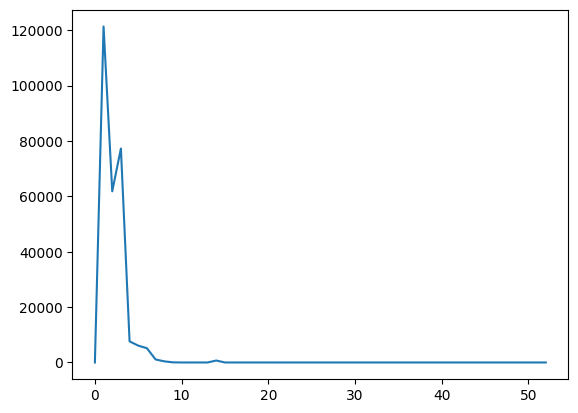

In [32]:
import matplotlib.pyplot as plt
plt.plot(loss_list)

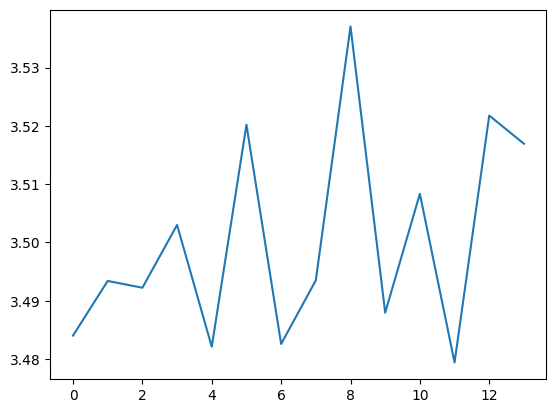

In [33]:
plt.plot(loss_test_list)